In [131]:
import jax
from flax import nnx
import optax

import numpy as np

In [132]:
from matplotlib import pyplot as plt

In [133]:
class Model(nnx.Module):
  def __init__(self, din, dmid, dout, rngs: nnx.Rngs):
    self.linear = nnx.Linear(din, dmid, rngs=rngs)
    self.bn = nnx.BatchNorm(dmid, rngs=rngs)
    self.dropout = nnx.Dropout(0.2, rngs=rngs)
    self.linear_out = nnx.Linear(dmid, dout, rngs=rngs)

  def __call__(self, x):
    x = nnx.relu(self.dropout(self.bn(self.linear(x))))
    return self.linear_out(x)


@nnx.jit  # automatic state management for JAX transforms
def train_step(model, optimizer, x, y):
  def loss_fn(model):
    y_pred = model(x)  # call methods directly
    return ((y_pred - y) ** 2).mean()

  loss, grads = nnx.value_and_grad(loss_fn)(model)
  optimizer.update(grads)  # in-place updates

  return loss

In [134]:
model = Model(2, 128, 3, rngs=nnx.Rngs(0))  # eager initialization

params = nnx.state(model, nnx.Param)
sum(x.size for x in jax.tree_util.tree_leaves(params))

1027

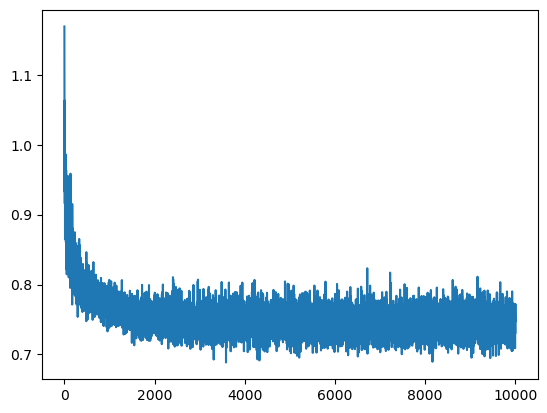

In [135]:
x = jax.random.normal(jax.random.key(42), (100,2))
y = jax.random.normal(jax.random.key(43), (100,3))

model = Model(2, 128, 3, rngs=nnx.Rngs(0))  # eager initialization
optimizer = nnx.Optimizer(model, optax.adam(1e-3))  # reference sharing


losses = []
i = np.arange(10000)
for _ in i:
    losses.append(train_step(model, optimizer, x, y))

plt.plot(i, losses)

In [137]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx

X = np.linspace(0, 1, 100)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)


def dataset(batch_size):
  while True:
    idx = np.random.choice(len(X), size=batch_size)
    yield X[idx], Y[idx]


class Linear(nnx.Module):
  def __init__(self, din: int, dout: int, *, rngs: nnx.Rngs):
    self.w = nnx.Param(jax.random.uniform(rngs.params(), (din, dout)))
    self.b = nnx.Param(jnp.zeros((dout,)))

  def __call__(self, x):
    return x @ self.w.value + self.b.value


class Count(nnx.Variable[nnx.A]):
  pass


class MLP(nnx.Module):
  def __init__(self, din, dhidden, dout, *, rngs: nnx.Rngs):
    self.count = Count(jnp.array(0))
    self.linear1 = Linear(din, dhidden, rngs=rngs)
    self.linear2 = Linear(dhidden, dout, rngs=rngs)

  def __call__(self, x):
    self.count.value += 1
    x = self.linear1(x)
    x = jax.nn.relu(x)
    x = self.linear2(x)
    return x


graphdef, params, counts = nnx.split(
  MLP(din=1, dhidden=32, dout=1, rngs=nnx.Rngs(0)), nnx.Param, Count
)


@jax.jit
def train_step(params, counts, batch):
  x, y = batch

  def loss_fn(params):
    model = nnx.merge(graphdef, params, counts)
    y_pred = model(x)
    new_counts = nnx.state(model, Count)
    loss = jnp.mean((y - y_pred) ** 2)
    return loss, new_counts

  grad, counts = jax.grad(loss_fn, has_aux=True)(params)
  #                          |-------- sgd ---------|
  params = jax.tree.map(lambda w, g: w - 0.1 * g, params, grad)

  return params, counts


@jax.jit
def test_step(params: nnx.State, counts: nnx.State, batch):
  x, y = batch
  model = nnx.merge(graphdef, params, counts)
  y_pred = model(x)
  loss = jnp.mean((y - y_pred) ** 2)
  return {'loss': loss}


In [138]:
total_steps = 10_000
for step, batch in enumerate(dataset(32)):
  params, counts = train_step(params, counts, batch)

  if step % 1000 == 0:
    logs = test_step(params, counts, (X, Y))
    print(f"step: {step}, loss: {logs['loss']}")

  if step >= total_steps - 1:
    break

step: 0, loss: 1.4618667364120483
step: 1000, loss: 0.00787450186908245
step: 2000, loss: 0.007876268588006496
step: 3000, loss: 0.007861742749810219
step: 4000, loss: 0.0077960798516869545
step: 5000, loss: 0.007774398662149906
step: 6000, loss: 0.00787450186908245
step: 7000, loss: 0.008085192181169987
step: 8000, loss: 0.007753720041364431
step: 9000, loss: 0.007911307737231255


times called: 10000


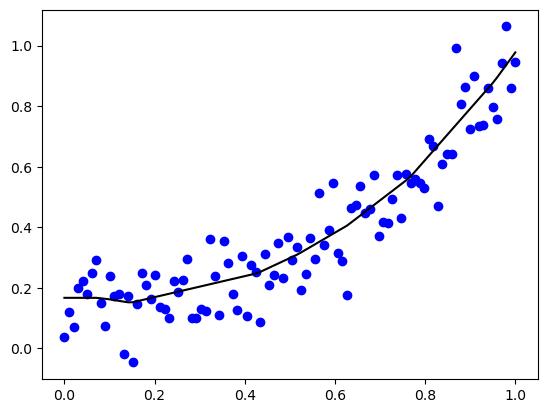

In [139]:
model = nnx.merge(graphdef, params, counts)
print('times called:', model.count.value)

y_pred = model(X)

plt.scatter(X, Y, color='blue')
plt.plot(X, y_pred, color='black')